In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Model_pollen import PollenModel
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

In [12]:
data = pd.read_csv("../data/weather_and_pollen.csv", parse_dates=["date"])
data.head()

,date,temp_mean,temp_min,temp_max,precip_sum,humidity_mean,wind_speed_mean,concentration
0,2017-01-01,1.716667,1.2,2.2,0.5,94.625000,20.662500,0.0
1,2017-01-02,-0.175000,-5.2,1.9,1.9,93.500000,15.029167,0.0
2,2017-01-03,-7.750000,-13.5,-3.0,1.2,86.083333,10.775000,0.0
3,2017-01-04,-11.383333,-14.7,-6.9,1.5,86.250000,11.787500,0.0
4,2017-01-05,-11.245833,-18.6,-6.6,5.4,83.500000,19.670833,0.0


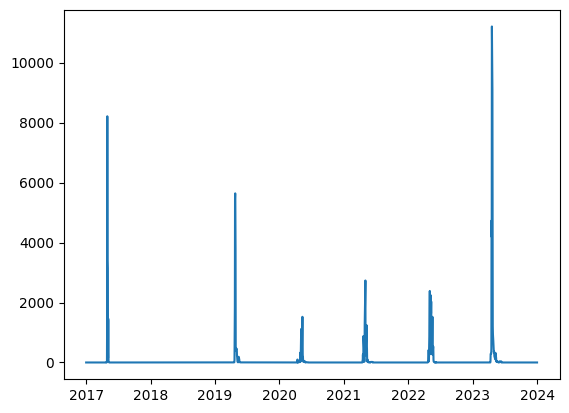

In [13]:
plt.plot(data['date'], data['concentration'])

In [14]:
preprocessing = Pipeline([
    ("standard_scaler", PollenModel.Preprocessing.StandardScalerFeature(
        ['temp_mean', 'temp_min', 'temp_max', 'precip_sum', 'humidity_mean', 'wind_speed_mean'],
        'concentration')),
])
splitter = PollenModel.Preprocessing.TrainValidationTest([2019, 2020, 2021, 202, 2023], [2019], random_state=1)

In [15]:
X, y = preprocessing.fit_transform(data)

In [16]:
X_train, X_valid, X_test, y_train, y_valid, y_test = splitter.fit(X, y)

d:\Project\pollen_prediction\src\Model_pollen.py:429: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['date'] = X_test['date'].astype('int64') // 10**9
d:\Project\pollen_prediction\src\Model_pollen.py:430: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid['date'] = X_valid['date'].astype('int64') // 10**9
d:\Project\pollen_prediction\src\Model_pollen.py:431: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [17]:
model_selecter = PollenModel.ModelSelection(
    mean_absolute_error,
    {'max_depth': [3, 5, 7],
     'learning_rate': [0.01, 0.05, 0.1],
     'subsample': [0.6, 0.8, 1.0],
     'colsample_bytree': [0.6, 0.8, 1.0],
     'reg_alpha': [0, 0.1, 0.5],
     'reg_lambda': [0, 1, 10],
     'n_estimators': [300],
     'random_state': [42],},
    tgdm=True
)

In [18]:
model = model_selecter.choose(X_train, y_train, X_valid, y_valid)

Parameter combinations:   0%|          | 0/1458 [00:00<?, ?it/s]

In [19]:
final = PollenModel.Finalize(model)
final.final_score(mean_absolute_error, X_valid, y_valid)

32.57464393835276

In [22]:
final.final_score(mean_absolute_error, X_test, y_test), final.final_score(r2_score, X_test, y_test)

(81.7571176140232, 0.1988479093459815)